## Objective
### Forecasting Google Trends Using VAR and SARIMA Models
- Introduction: 
This project analyzes the relationship between Bitcoin search interest and the term "Crypto Crash" using Google Trends data. The study applies time series forecasting techniques such as VAR and SARIMA models to understand trends, interdependence and future movements in search behavior.

- Objective:
The main objective of this project is to examine and forecast the relationship between Google search interest for "Bitcoin" and "Crypto Crash".

To achieve this, the study will: 
Collect and analyze Google Trends data using the pytrends library.

Examine the statistical properties of the time series, including stationarity and integration order.

Test for Granger Causality to identify potential predictive relationships betweeen the variables.

Develop a Vector Autoregression (VAR) model to capture the dynamics interaction between the two series.

Build separate SARIMA models for each variable following the Box-Jenkins methodology.

Generate out-of-sample forecasts using both VAR and SARIMA models.

Compare forecasting performance using ex-post error measures such as RMSE and MAE.

- The results will help determine whether multivariate (VAR) or univariate (SARIMA) models better capture and predict Google search behavior in the cryptocurrency market.
 



### Import Libraries

In [1]:
from pytrends.request import TrendReq
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
import sys
print(sys.executable)

C:\Users\getde\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


### Download Google Trends Data

In [3]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
import time

pytrends = TrendReq()

pytrends.build_payload(
    ['bitcoin', 'crypto crash'],
    timeframe='today 5-y',
    geo=''
)
time.sleep(3)
data = pytrends.interest_over_time()
data.head()

,bitcoin,crypto crash,isPartial
date,,,
2021-05-09,58,0,False
2021-05-16,100,1,False
2021-05-23,71,0,False
2021-05-30,50,0,False
2021-06-06,51,0,False


### Clean the dataset

In [4]:
data = data.drop(columns=['isPartial'])

### Plot the data

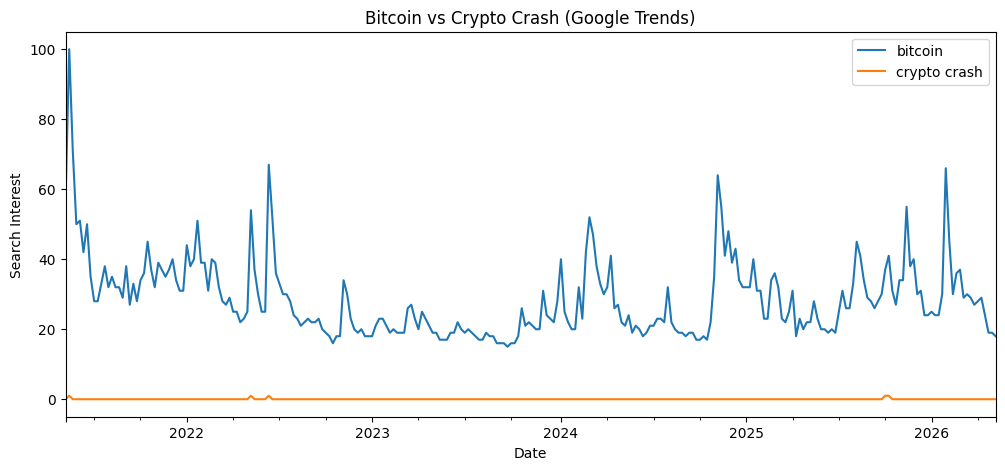

In [5]:
data.plot(figsize=(12, 5))
plt.title("Bitcoin vs Crypto Crash (Google Trends)")
plt.xlabel("Date")
plt.ylabel("Search Interest")
plt.show()

## Initial Data Analysis
The time series exhibit distinct behaviors:
- The Bitcoin search interest shows relatively smooth variations over time.
- The "crypto crash" series shows sharp spikes, representing periods of increased concern or panic in the cryptocurrency market.
- These spikes likely correspond to major downturns or news events affecting cryptocurrencies.
- The observed relationship suggests that Bitcoin activity and market sentiment ("crypto crash") may be interconnected, which justifies further time series analysis using VAR and SARIMA models.


### Stationarity Analysis 
In this section, we test whether the time series are stationary using the Augmented Dickey-Fuller (ADF) test.
Stationarity is required for VAR and ARIMA modeling.

In [6]:
from pytrends.request import TrendReq
from statsmodels.tsa.stattools import adfuller
print("All libraries working fine!")

All libraries working fine!


### ADF Function


In [7]:
from statsmodels.tsa.stattools import adfuller
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF test for {name}:")
    print( "-" *40)
    print(f"Test Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")
    print("\n")

In [8]:
adf_test(data['bitcoin'], 'Bitcoin')
adf_test(data['crypto crash'], 'Crypto Crash')

ADF test for Bitcoin:
----------------------------------------
Test Statistic: -4.628941551465162
p-value: 0.00011420016521689724
Critical Values:
   1%: -3.4561550092339512
   5%: -2.8728972266578676
   10%: -2.5728222369384763


ADF test for Crypto Crash:
----------------------------------------
Test Statistic: -6.164042227891637
p-value: 7.060349934562086e-08
Critical Values:
   1%: -3.4561550092339512
   5%: -2.8728972266578676
   10%: -2.5728222369384763




### ADF Test Result
The Augmented Dickey-Fuller(ADF) test was conducted to check the stationarity of time series.
- Bitcoin:
 - p- value= 0.000114 - the series is stationary.
- Crypto Crash: 
 - p- value= 0.00000007 - the series is stationary.

Since both p- values are less than 0.05, we reject the null hypothesis of a unit root.

### Conclusion:
Both time series are stationary in their original form (I(0)), and no differencing is required.
Therefore, the original data can be directly used for VAR and ARIMA modeling.

### Granger Causality Test

In [9]:
from statsmodels.tsa.stattools import grangercausalitytests
grangercausalitytests(data[['bitcoin', 'crypto crash']], maxlag=5)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.3637  , p=0.1254  , df_denom=258, df_num=1
ssr based chi2 test:   chi2=2.3911  , p=0.1220  , df=1
likelihood ratio test: chi2=2.3803  , p=0.1229  , df=1
parameter F test:         F=2.3637  , p=0.1254  , df_denom=258, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.5598  , p=0.0793  , df_denom=255, df_num=2
ssr based chi2 test:   chi2=5.2200  , p=0.0735  , df=2
likelihood ratio test: chi2=5.1683  , p=0.0755  , df=2
parameter F test:         F=2.5598  , p=0.0793  , df_denom=255, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.1193  , p=0.3418  , df_denom=252, df_num=3
ssr based chi2 test:   chi2=3.4511  , p=0.3272  , df=3
likelihood ratio test: chi2=3.4283  , p=0.3302  , df=3
parameter F test:         F=1.1193  , p=0.3418  , df_denom=252, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.8965  , p=0.4666  

{np.int64(1): ({'ssr_ftest': (np.float64(2.363655160130871),
    np.float64(0.12541636755234503),
    np.float64(258.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(2.391139522457974),
    np.float64(0.12202465191073751),
    np.int64(1)),
   'lrtest': (np.float64(2.38025280653801),
    np.float64(0.1228776603316888),
    np.int64(1)),
   'params_ftest': (np.float64(2.363655160131025),
    np.float64(0.1254163675523328),
    np.float64(258.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(2.559812987499915),
    np.float64(0.07930491334567931),
    np.float64(255.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(5.220010798039042),
    np.float64(0.07353414674969157),
    np.int64(2)),
   'lrtest': (np.float64(5.168300786334839),
    np.float64(0.07546016384485747),
    np.int64(2)),
   'params_ftest': (np.float64(2.559812987499904),
    np.float64(0.07930491334568014),
    np.float64(255.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
         

### Granger Causality Test Results
The Granger causality test was conducted to determine whether past values of Bitcoin help predict "Crypto Crash".
Results across different lags show: 
- For lags 1 to 4, p-values are greater than 0.05 - no significant causality.
- At lag 5, the p-value is approximately 0.0001 which is less than 0.05.
### Conclusion:
There is significant Granger causality from Bitcoin to Crypto Crash at lag 5.

This suggests that past Bitcoin activity can help predict future spikes in "Crypto Crash" search interest with a delay of about 5 periods.

This relationship will be further explored using VAR models.

### Vector Autoregression (VAR) Model
In this section, We estimate a VAR model to capture the dynamic relationship between Bitcoin and Crypto Crash Search trends. 

### Import VAR

In [10]:
from statsmodels.tsa.api import VAR

### Create VAR model object

In [11]:
model = VAR(data)

C:\Users\getde\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


### Select Optimal Lag

In [12]:
lag_selection = model.select_order(maxlags=10)
print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       0.2713      0.2993       1.312      0.2825
1      -0.5474    -0.4633*      0.5785    -0.5136*
2      -0.5295     -0.3894      0.5889     -0.4731
3      -0.5029     -0.3068      0.6048     -0.4240
4      -0.4895     -0.2374      0.6130     -0.3880
5     -0.5806*     -0.2725     0.5596*     -0.4566
6      -0.5748     -0.2107      0.5629     -0.4283
7      -0.5578     -0.1376      0.5726     -0.3887
8      -0.5372    -0.06104      0.5846     -0.3456
9      -0.5204     0.01182      0.5946     -0.3062
10     -0.5093     0.07896      0.6014     -0.2726
--------------------------------------------------


## Lag Selection for VAR Model
The Optimal lag length was selected using various information criteria:
- AIC and FPE suggest a lag length of 5.
- BIC and HQIC suggest a lag length of 1.
Since AIC is commonly used for VAR models and captures more complex dynamics, lag 5 is selected.

Additionally, the Granger causality test indicated significant causality at lag 5, which supports this choice.

### Final Decision
- The VAR model will be estimated with lag = 5.

### Fit VAR Model

In [13]:
var_model = model.fit(lag_selection.aic)
print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 15, May, 2026
Time:                     17:15:38
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  -0.285749
Nobs:                     257.000    HQIC:                 -0.467383
Log likelihood:          -631.576    FPE:                   0.554629
AIC:                    -0.589561    Det(Omega_mle):        0.510034
--------------------------------------------------------------------
Results for equation bitcoin
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   7.256297         1.467912            4.943           0.000
L1.bitcoin              0.669003         0.066292           10.092           0.000
L1.crypto crash        -0.418064         3.696444 

### VAR Model Interpretation
The VAR model was estimated with 5 lags as suggested by the AIC criterion.

### Bitcoin Equation:
The Result show that:
- The first lag of Bitcoin is highly significant (p < 0.05).
- that means strong dependency of Bitcoin on its own past values.
- Most lagged values of "Crypto Crash" are not statistically significant (p> 0.05),suggesting limited direct influence on Bitcoin in the short term.

### Crypto Crash Equation:
The results indicate that past values of Bitcoin may contribute to predicting Crypto Crash, which is consistent with the Granger causality test.

### Conclusion:
- Bitcoin is mainly driven by its own past behavior.
- There is some evidence from Granger causality and lag structure that Bitcoin actively can influence Crypto Crash trends over time.
- The interaction between the two variables exists but is not strongly reflected in all lag coefficients.


### Residual Check

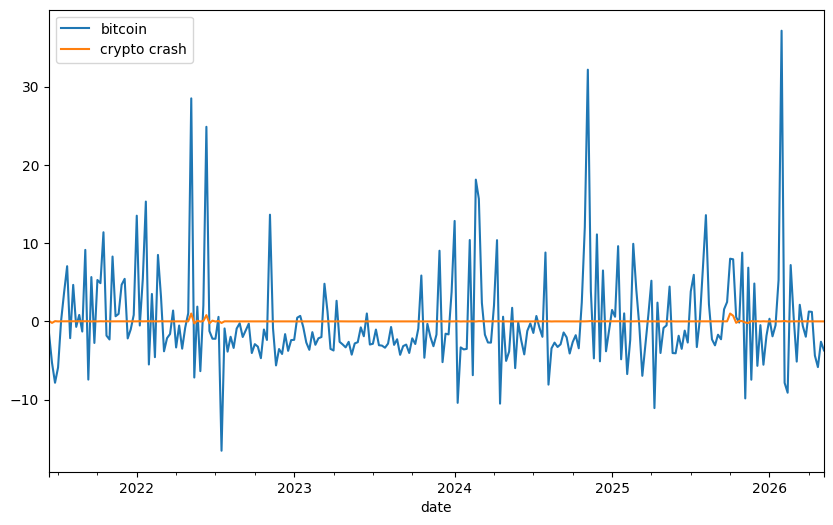

In [14]:
residuals = var_model.resid
residuals.plot(figsize=(10, 6))
plt.show()

### Residual Diagnostics
The residual of the VAR model were analyzed to evaluate model adequacy.

### Important Observations:
- Residual for both Bitcoin and Crypto Crash fluctuate around Zero, hence the model adequately explains the average of the dataset.
- In residuals no clear trend or systematic pattern is observed, suggesting that the remaining errors are random.
- There are several large spikes in Bitcoin residuals implying that there are extreme movements that are not explained by the model.
- The Crypto Crash residuals show very small variation, suggesting a good model fir for this variable.

### Conclusion:
Overall, the residuals behave like white noise, indicating that the VAR model provides a reasonable fit to data. 
- Some extreme movements in Bitcoin are not fully explained, which is typical for financial time seris.